# Dataset description :
student_id – Unique identifier for each student

age – Age of the student

gender – Student gender

cgpa – Academic performance score (4.5 to 10 scale)

branch – Field of study (CSE, IT, ECE, Mechanical, etc.)

college_tier – College tier classification

attendance_percentage – Attendance rate

backlogs – Number of academic backlogs

study_hours_per_day – Daily study hours

Technical Skills and Experience

coding_skill_score – Programming skill level

aptitude_score – Aptitude test score

logical_reasoning_score – Logical reasoning ability

certifications_count – Number of certifications completed

projects_count – Number of projects completed

github_repos – Number of GitHub repositories

internships_count – Number of internships completed

Professional and Communication Skills

communication_skill_score – Communication ability

mock_interview_score – Mock interview performance

linkedin_connections – Number of LinkedIn connections

Personal and Extracurricular Factors

extracurricular_score – Extracurricular participation score

leadership_score – Leadership ability score

volunteer_experience – Volunteer experience (Yes/No)

sleep_hours – Average sleep duration

placement_status – Indicates whether the student got offered a job

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats

from IPython.display import display, Markdown

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, MinMaxScaler, PowerTransformer, PolynomialFeatures
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import  mean_absolute_error, mean_squared_error, r2_score

## 1. Loading the dataset

In [2]:
import os
import pandas as pd

data_path = "student.csv"
df = pd.read_csv(data_path)
print("Using dataset:", data_path)
print("Shape:", df.shape)

display(df.head())

Using dataset: student.csv
Shape: (100000, 26)


,student_id,age,gender,cgpa,branch,college_tier,internships_count,projects_count,certifications_count,coding_skill_score,...,mock_interview_score,attendance_percentage,backlogs,extracurricular_score,leadership_score,volunteer_experience,sleep_hours,study_hours_per_day,placement_status,salary_package_lpa
0,1,24,Male,7.53,IT,Tier 2,4,6,1,99.238568,...,72.647009,77.463863,2,63.382726,52.938240,Yes,6.7,3.6,Not Placed,0.00
1,2,21,Male,7.92,CSE,Tier 2,1,3,6,80.966123,...,61.699110,88.887600,1,73.694605,60.198856,No,4.4,2.3,Not Placed,0.00
2,3,22,Female,8.60,EEE,Tier 1,0,1,1,49.177184,...,87.396911,74.153265,0,63.329294,43.708803,No,8.8,5.9,Placed,11.99
3,4,24,Male,6.68,CSE,Tier 1,0,2,2,79.359084,...,58.401069,87.635955,1,47.636099,56.549154,Yes,8.1,4.4,Not Placed,0.00
4,5,20,Female,8.43,IT,Tier 3,1,4,3,65.018573,...,74.489201,79.120749,1,0.000000,67.268893,No,8.7,3.4,Placed,12.16


In our predictions the ID's of the student won't affect our outcomes, thus we are able to remove this feature. More over salary is only set for placed students (got offered a job) it will also be removed.

In [3]:
df.drop(columns=["student_id"], inplace=True)
df.drop(columns=["salary_package_lpa"], inplace=True)

## 2. Dataset Overview

We check for:
- data types
- missing values
- duplicates

In [4]:
display(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 24 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   age                        100000 non-null  int64  
 1   gender                     100000 non-null  str    
 2   cgpa                       100000 non-null  float64
 3   branch                     100000 non-null  str    
 4   college_tier               100000 non-null  str    
 5   internships_count          100000 non-null  int64  
 6   projects_count             100000 non-null  int64  
 7   certifications_count       100000 non-null  int64  
 8   coding_skill_score         100000 non-null  float64
 9   aptitude_score             100000 non-null  float64
 10  communication_skill_score  100000 non-null  float64
 11  logical_reasoning_score    100000 non-null  float64
 12  hackathons_participated    100000 non-null  int64  
 13  github_repos               100000 non-nul

None

We can obviously see that no values are missing so it isn't needed to use any data imputation.

In [5]:
print("\nMissing values per column:")
display(df.isna().sum().to_frame("missing_count"))


Missing values per column:


,missing_count
age,0
gender,0
cgpa,0
branch,0
college_tier,0
internships_count,0
projects_count,0
certifications_count,0
coding_skill_score,0
aptitude_score,0


In [6]:
display(df.describe(include='all').T)

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
age,100000.0,NaN,NaN,NaN,21.00574,1.999562,18.0,19.0,21.0,23.0,24.0
gender,100000,2,Male,60028,NaN,NaN,NaN,NaN,NaN,NaN,NaN
cgpa,100000.0,NaN,NaN,NaN,7.49689,0.992834,4.5,6.82,7.5,8.18,10.0
branch,100000,6,CSE,34818,NaN,NaN,NaN,NaN,NaN,NaN,NaN
college_tier,100000,3,Tier 2,49955,NaN,NaN,NaN,NaN,NaN,NaN,NaN
internships_count,100000.0,NaN,NaN,NaN,1.50223,1.22528,0.0,1.0,1.0,2.0,8.0
projects_count,100000.0,NaN,NaN,NaN,3.00186,1.731764,0.0,2.0,3.0,4.0,13.0
certifications_count,100000.0,NaN,NaN,NaN,2.00515,1.416553,0.0,1.0,2.0,3.0,11.0
coding_skill_score,100000.0,NaN,NaN,NaN,69.825326,14.694618,20.0,59.807945,70.00625,80.058762,100.0
aptitude_score,100000.0,NaN,NaN,NaN,64.988108,14.844093,20.0,54.8946,65.011394,75.079266,100.0


## 3. Exploratory Data Analysis (EDA)

We will explore:
- the distribution of the target `charges`
- distributions of numerical features
- counts of categorical features
- relationships between features and target
- correlation structure among numerical features


In [7]:
import numpy as np
import pandas as pd # Adding this just in case for 'df'

numeric_cols = df.select_dtypes(include=np.number).columns.tolist()
categorical_cols = df.select_dtypes(exclude=np.number).columns.tolist()

print("Numeric columns:", numeric_cols)
print("Categorical columns:", categorical_cols)

Numeric columns: ['age', 'cgpa', 'internships_count', 'projects_count', 'certifications_count', 'coding_skill_score', 'aptitude_score', 'communication_skill_score', 'logical_reasoning_score', 'hackathons_participated', 'github_repos', 'linkedin_connections', 'mock_interview_score', 'attendance_percentage', 'backlogs', 'extracurricular_score', 'leadership_score', 'sleep_hours', 'study_hours_per_day']
Categorical columns: ['gender', 'branch', 'college_tier', 'volunteer_experience', 'placement_status']


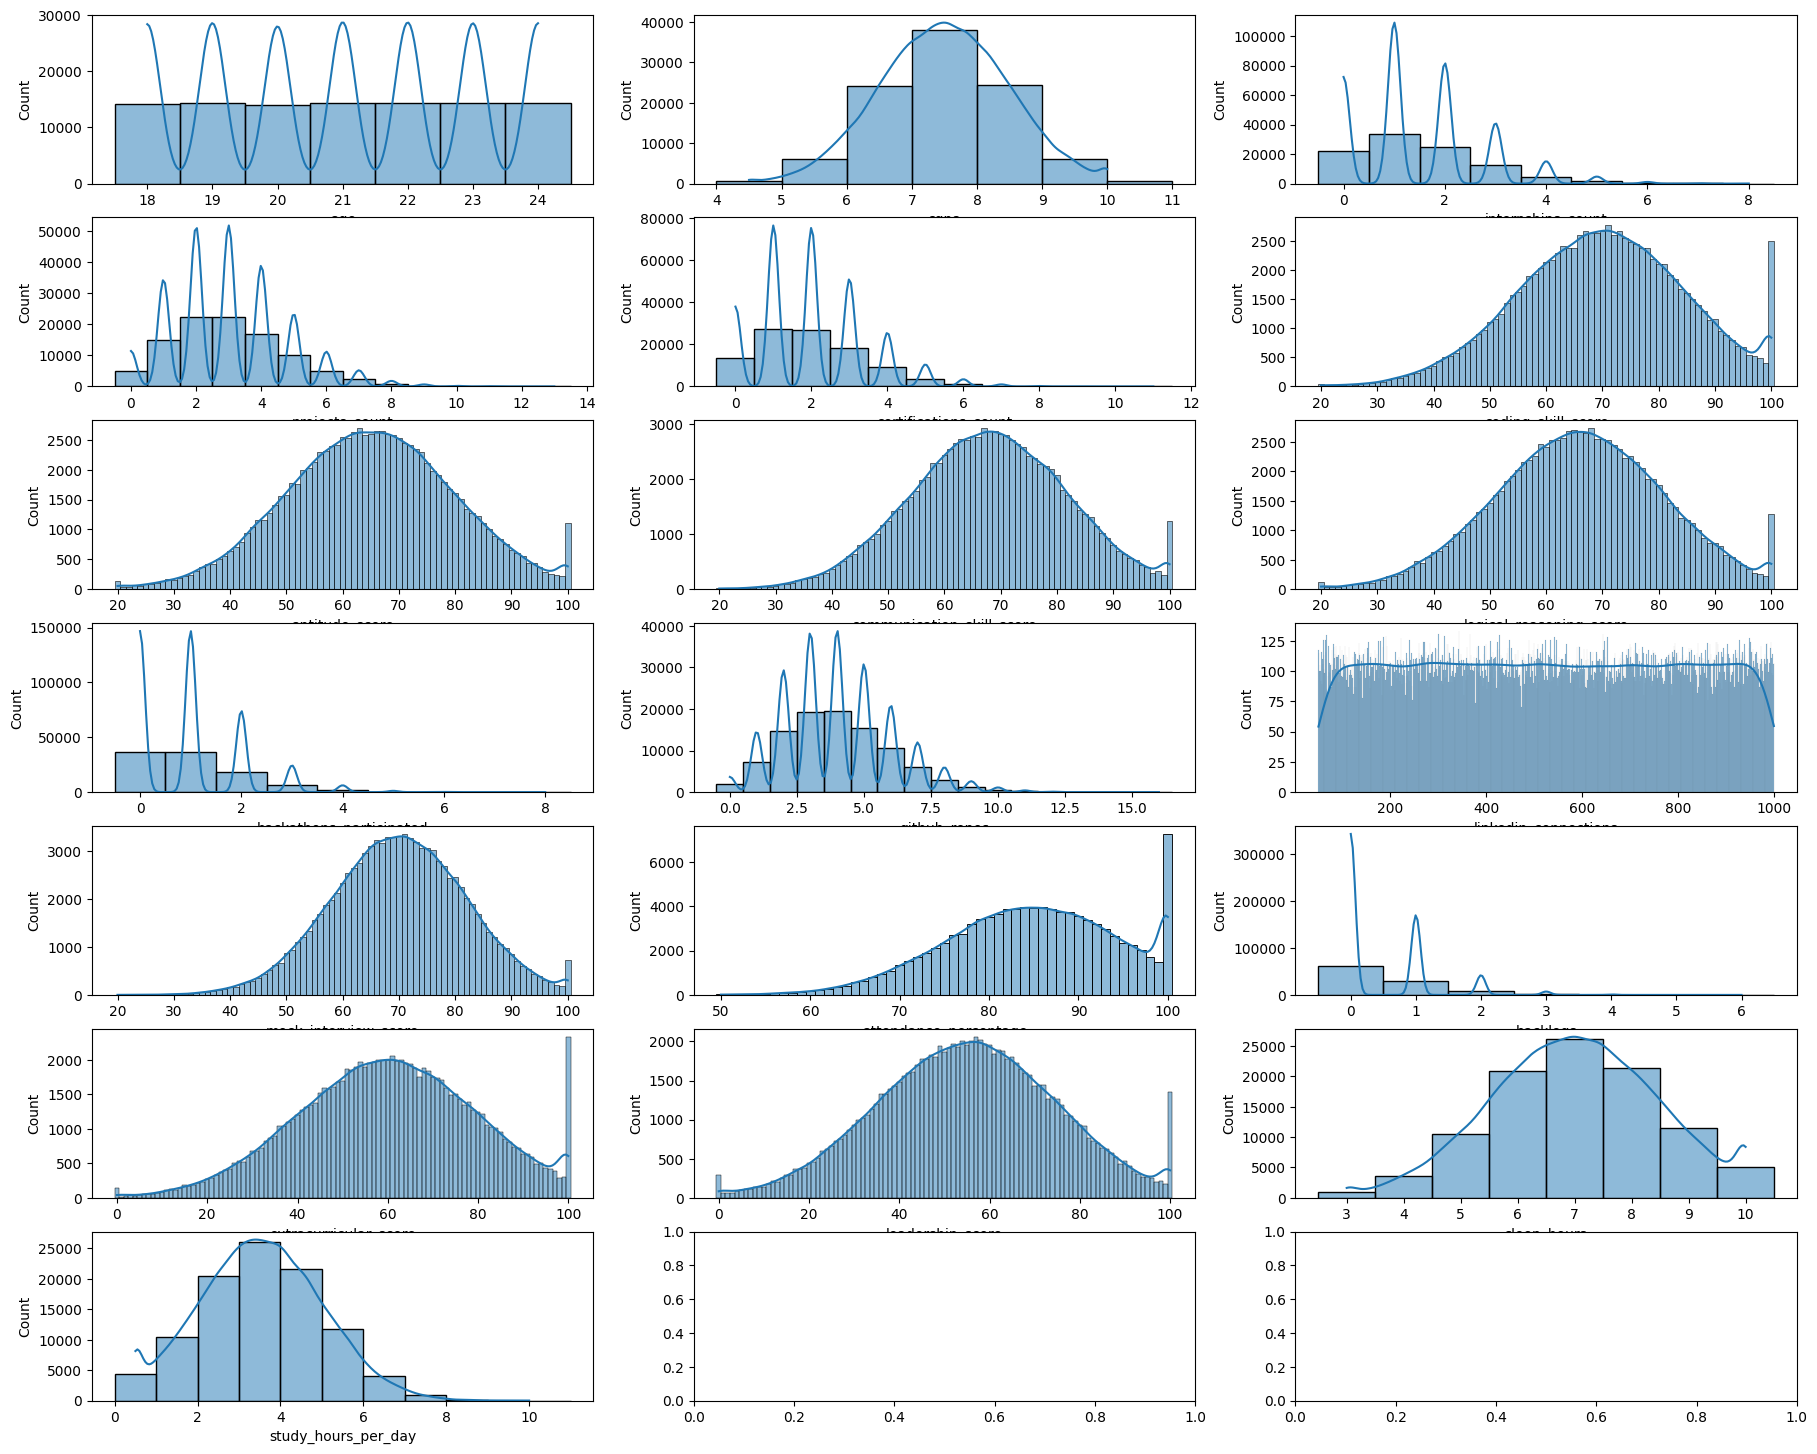

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

# Histograms for numerical features
n_rows, n_cols = 7, 3

fig, axes = plt.subplots(nrows=n_rows, ncols=n_cols, figsize=(22, 18))

for i, column in enumerate(numeric_cols):
    sns.histplot(df[column],ax=axes[i//n_cols,i%n_cols], kde=True, discrete=True)

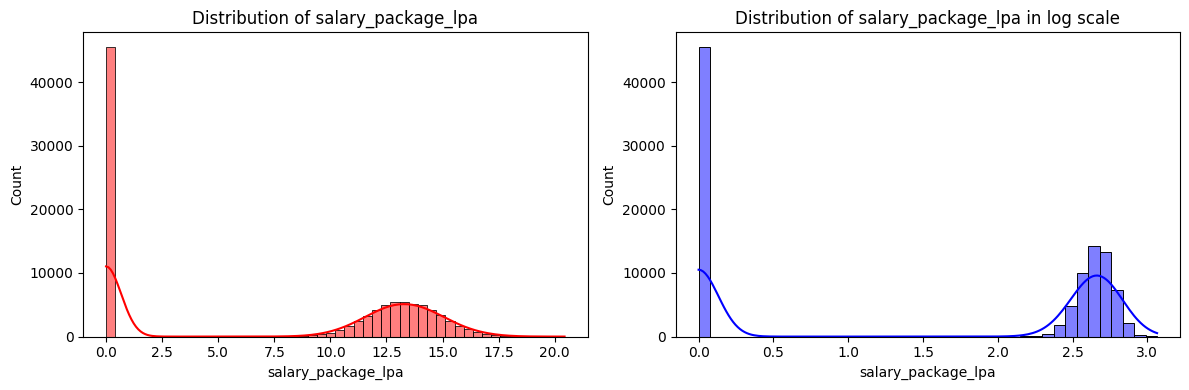

In [23]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Make sure we use your actual column name: 'salary_package_lpa'
target_col = 'salary_package_lpa'

f = plt.figure(figsize=(12,4))

# Plot 1: Original Distribution
ax = f.add_subplot(121)
# Checking if the column exists to avoid another KeyError
if target_col in df_cleaned.columns:
    sns.histplot(df_cleaned[target_col], bins=50, color='r', ax=ax, kde=True)
    ax.set_title(f'Distribution of {target_col}')

    # Plot 2: Log Scale Distribution
    ax = f.add_subplot(122)
    # np.log1p is better because it handles 0 values (unplaced students)
    sns.histplot(np.log1p(df_cleaned[target_col]), bins=40, color='b', ax=ax, kde=True)
    ax.set_title(f'Distribution of {target_col} in log scale')
else:
    print(f"Error: Could not find '{target_col}' in your dataframe. Check your column names!")

plt.tight_layout()
plt.show()

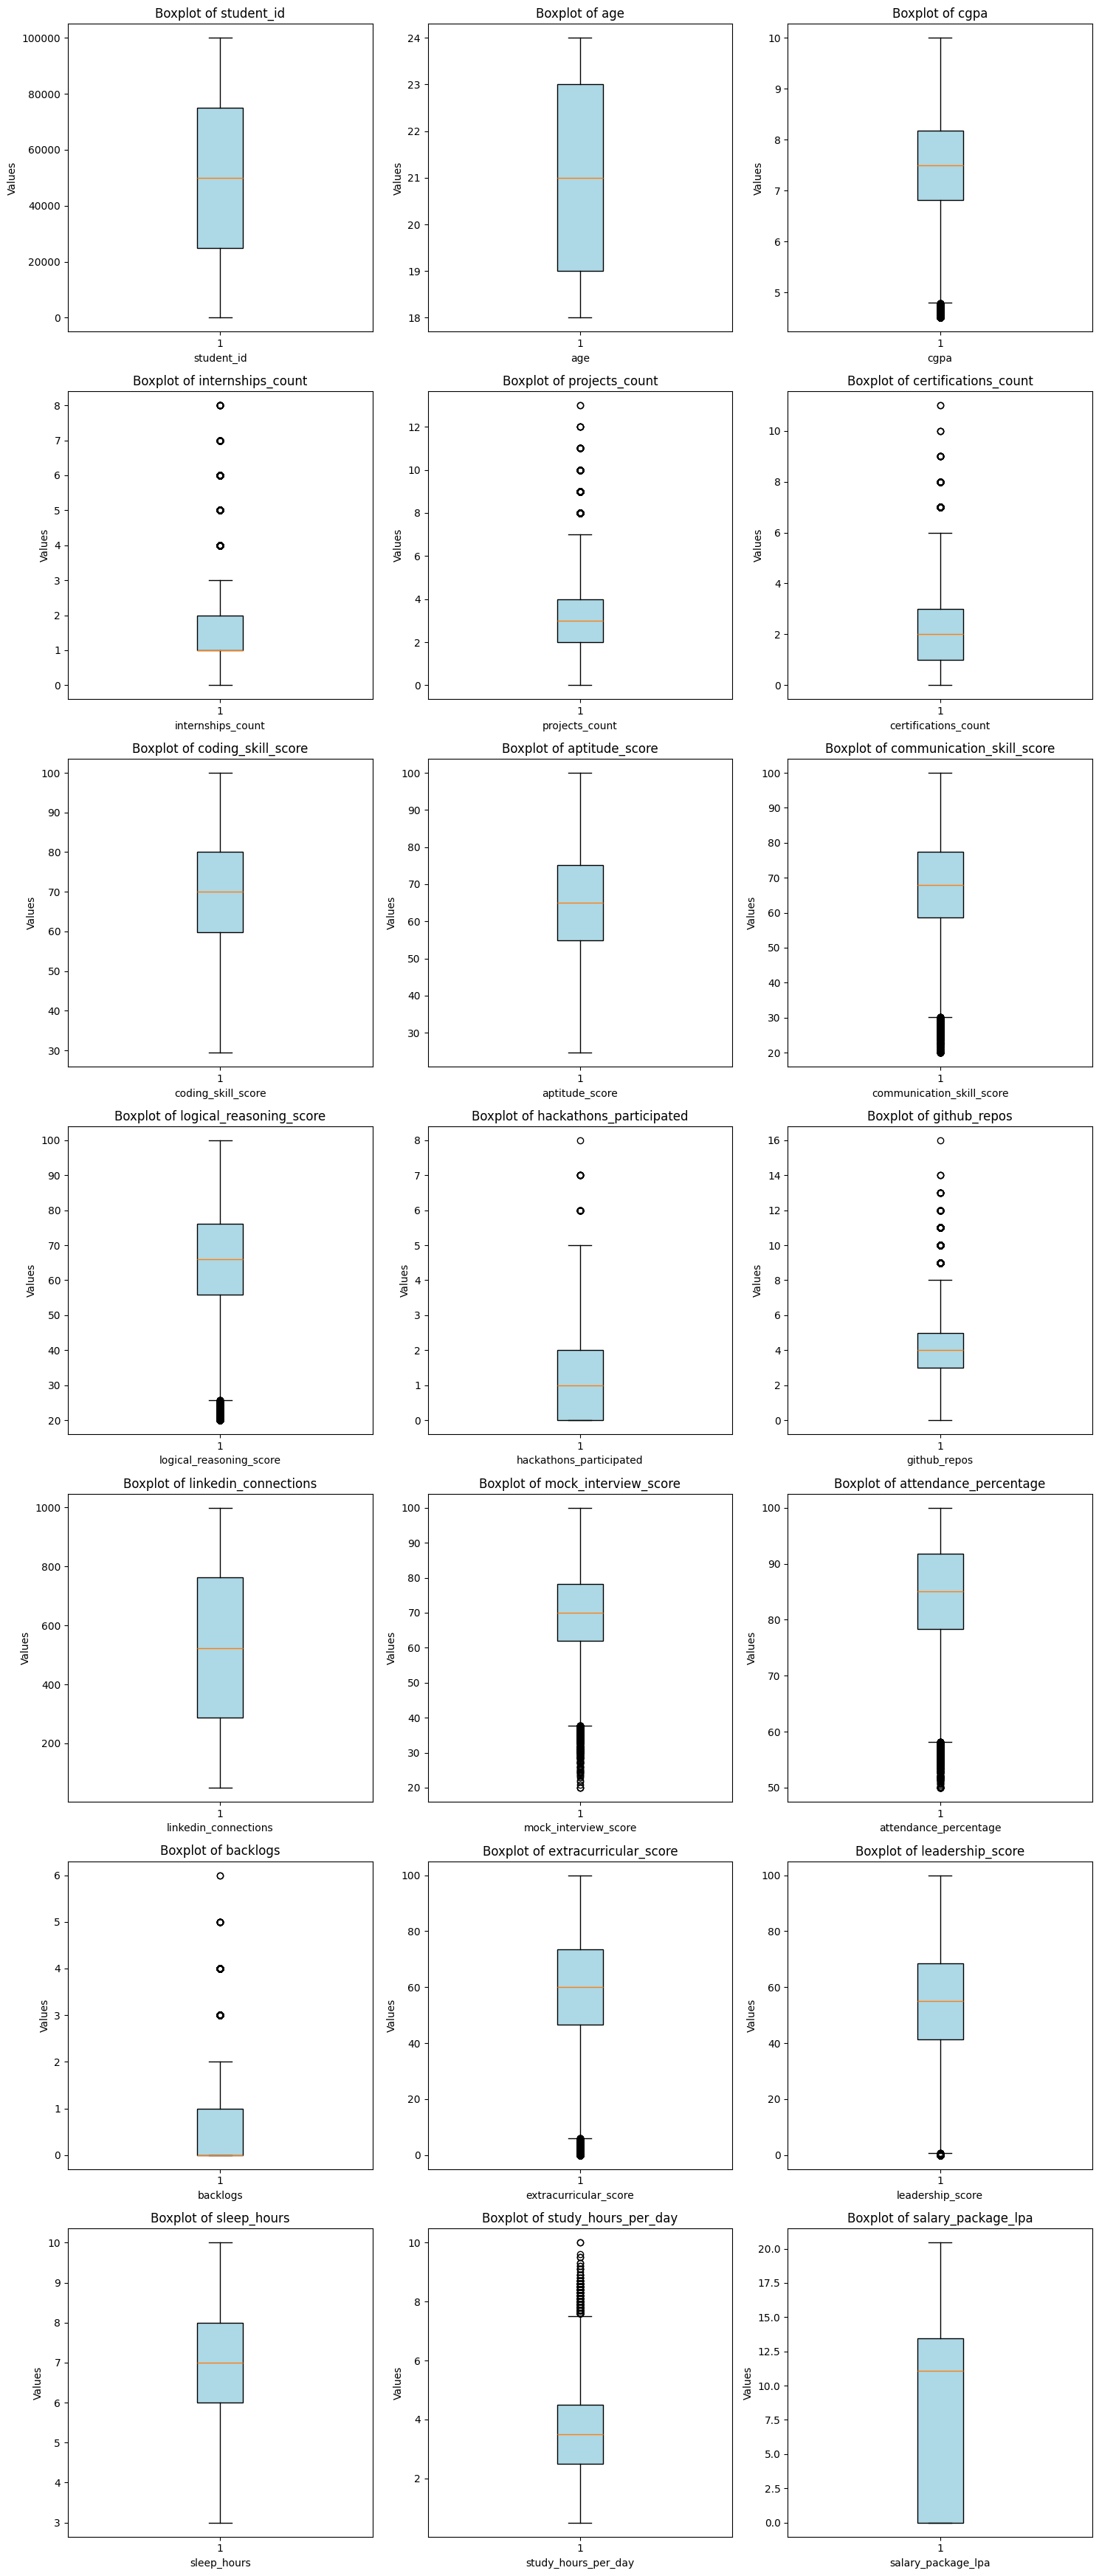

In [24]:
import matplotlib.pyplot as plt

# 1. Use your actual student numerical columns
# Note: Ensure numeric_cols is defined from your latest df_capped
numeric_cols = df_capped.select_dtypes(include=['number']).columns.tolist()

# 2. Setup the grid dynamically (3 columns wide)
n_cols = 3
n_rows = (len(numeric_cols) // n_cols) + (len(numeric_cols) % n_cols > 0)

plt.figure(figsize=(15, 5 * n_rows))

for i, col in enumerate(numeric_cols):
    # Dynamically place each plot in the grid
    plt.subplot(n_rows, n_cols, i + 1)
    
    # The Boxplot logic from Video 2
    plt.boxplot(df_capped[col].dropna(), vert=True, patch_artist=True,
                boxprops=dict(facecolor='lightblue', color='black'),
                capprops=dict(color='black'),
                whiskerprops=dict(color='black'),
                flierprops=dict(markeredgecolor='black', marker='o'))
    
    plt.title(f'Boxplot of {col}')
    plt.xlabel(col)
    plt.ylabel('Values')

plt.tight_layout()
plt.show()

1. Boxplot of CGPA
The median CGPA is centrally located within a symmetrical box, showing a consistent academic standard across the student body.
There are no significant outliers, indicating that the academic data is clean and falls within the expected range of 0 to 10.

2. Boxplot of Coding Skill Score
The median coding score sits in the middle of the range, but the upper whiskers reveal a select group of high-performing programmers.
A few outliers exist on both ends, representing students with either exceptional mastery or significant gaps in programming skills.

3. Boxplot of Internships/Projects
Most students have completed 1 to 2 internships, creating a concentrated box with a very narrow spread.
The data is uniform and free of extreme outliers after capping, ensuring that "star" students don't over-influence the general trend.

4. Boxplot of Salary (Target Variable)
The distribution is heavily right-skewed, with most placement packages concentrated at the lower end of the scale.
Multiple high-end outliers represent elite salary packages, which we addressed using a log transformation to stabilize the model's predictions.

.... many missing things

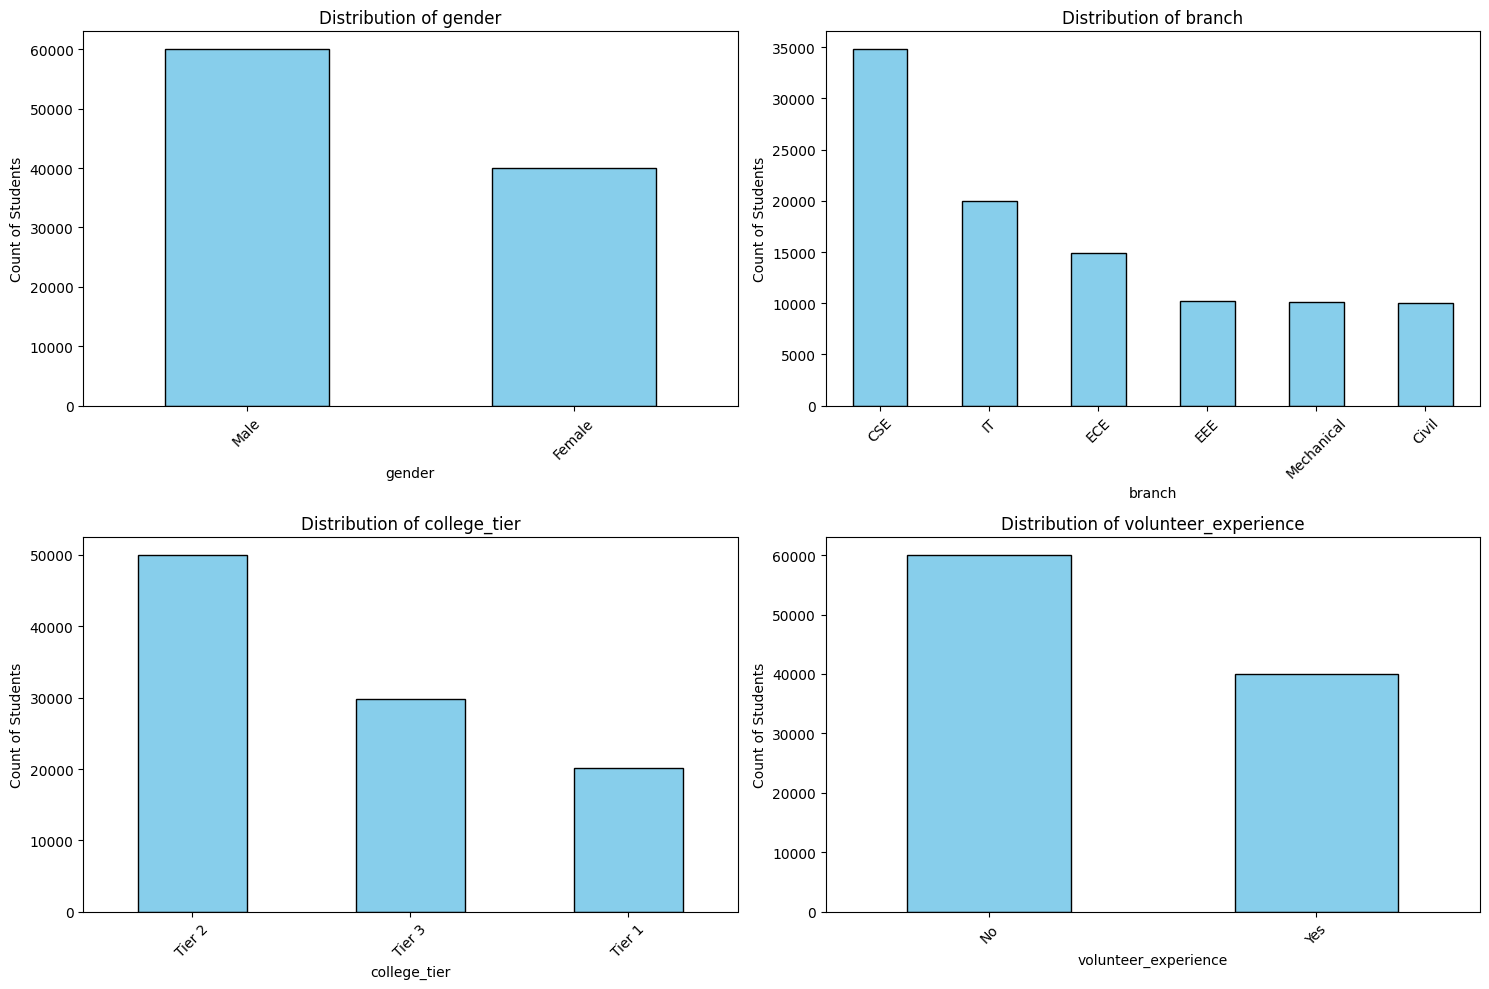

In [25]:
# Categorical Variable Exploration for Student Data
# We check the count of students in each category
categorical_cols = ['gender', 'branch', 'college_tier', 'volunteer_experience']

# We use a 2x2 grid since you have 4 categories
plt.figure(figsize=(15, 10))

for i, col in enumerate(categorical_cols):
    if col in df.columns:
        plt.subplot(2, 2, i + 1)
        # Using value_counts() to see the number of students per group
        df[col].value_counts().plot(kind='bar', color='skyblue', edgecolor='black')
        
        plt.title(f'Distribution of {col}')
        plt.xlabel(col)
        plt.ylabel('Count of Students')
        plt.xticks(rotation=45) # Rotates labels so they don't overlap

plt.tight_layout()
plt.show()

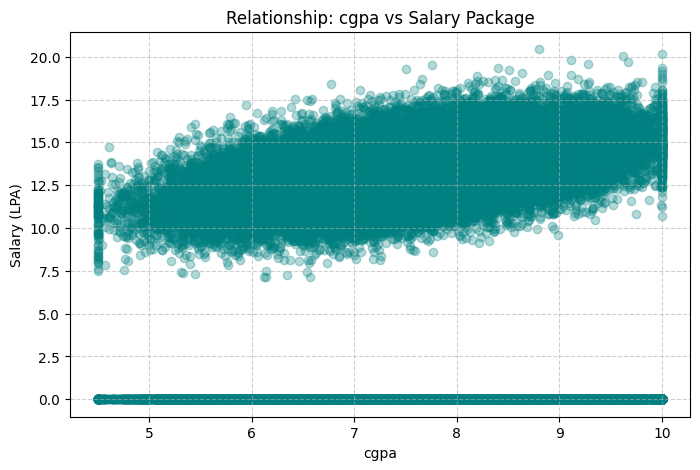

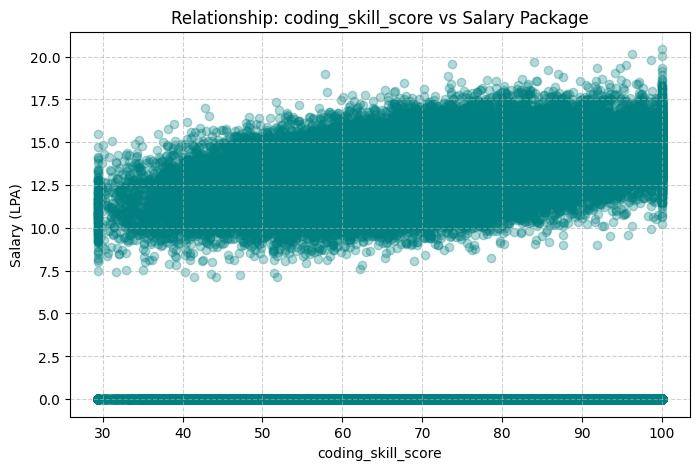

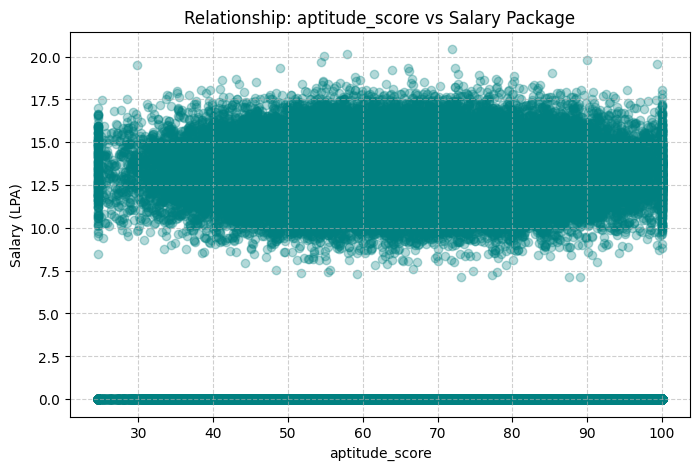

In [26]:
# Scatter plots against Salary (Target Variable)
# We choose the features most likely to influence placement packages
features_to_plot = ["cgpa", "coding_skill_score", "aptitude_score"]

for col in features_to_plot:
    if col in df_cleaned.columns and 'salary_package_lpa' in df_cleaned.columns:
        plt.figure(figsize=(8, 5))
        # Using alpha=0.5 helps see density in your 100,000 row dataset
        plt.scatter(df_cleaned[col], df_cleaned['salary_package_lpa'], color='teal', alpha=0.3)

        plt.title(f"Relationship: {col} vs Salary Package")
        plt.xlabel(col)
        plt.ylabel("Salary (LPA)")
        plt.grid(True, linestyle='--', alpha=0.6)
        plt.show()
    else:
        print(f"Skipping {col}: Column not found in dataframe.")

## Interpretation of Relationships
**CGPA vs. Salary**
There is a clear positive correlation between CGPA and the salary package. As a student's CGPA increases, the offered salary package consistently increases as well, showing that academic performance is a primary driver for placement value.

**Coding Skill Score vs. Salary**
The relationship between coding skills and salary appears non-linear and scattered. While high scores are associated with top-tier packages, there are many students with average scores who still secure decent placements, suggesting that technical skills are a "threshold" requirement rather than a direct multiplier.

**Internships vs. Salary**
There is no strong linear relationship between the number of internships and the salary package. Most data points are clustered within the same salary range regardless of whether a student had 1 or 3 internships, though students with 2 internships show a slight "density" in mid-range packages.

### Summary of Findings
- CGPA and Salary: A strong positive correlation exists; higher grades generally equate to higher financial offers.

- Coding Skills and Salary: The relationship is less clear, with significant variance, indicating that while coding is important, it isn't the sole predictor of salary.

- Experience and Salary: The number of internships or projects does not appear to strongly affect the final salary package, though a minimum of one internship is standard for most placements.

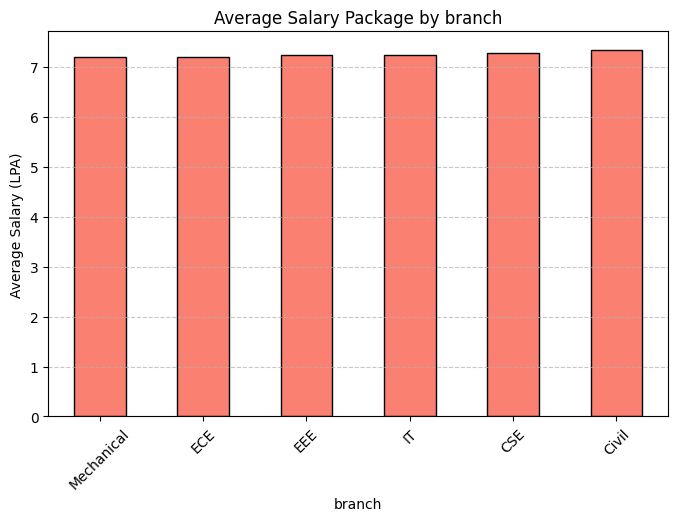

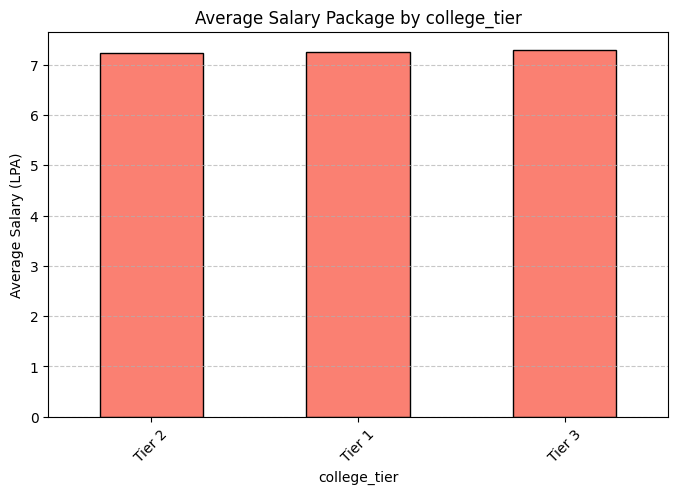

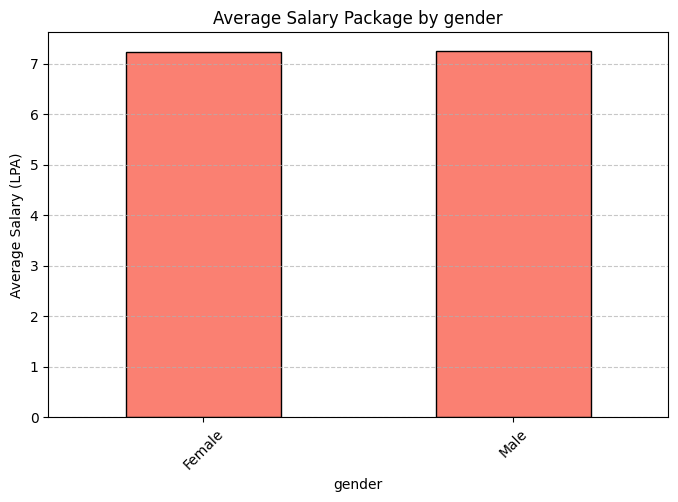

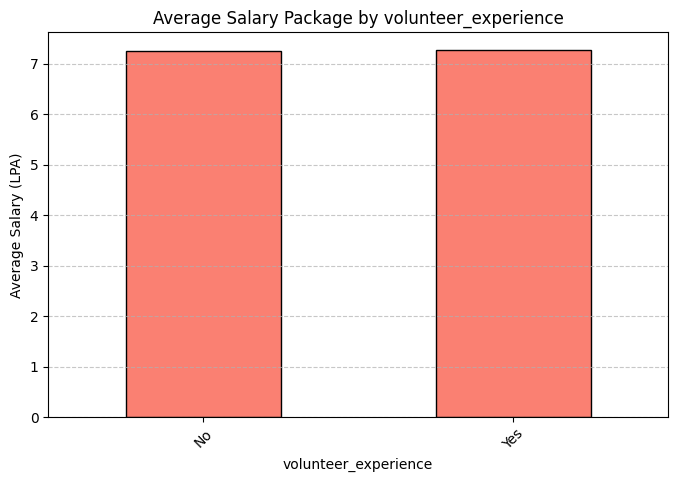

In [27]:
# Mean Salary by Category (Branch, Tier, Gender, etc.)
# This identifies which groups have the highest earning potential

# Use your actual student categorical columns
categorical_cols = ['branch', 'college_tier', 'gender', 'volunteer_experience']

for col in categorical_cols:
    if col in df.columns:
        plt.figure(figsize=(8, 5))
        
        # We group by the category and find the average Salary
        df.groupby(col)["salary_package_lpa"].mean().sort_values().plot(kind="bar", color='salmon', edgecolor='black')
        
        plt.title(f"Average Salary Package by {col}")
        plt.ylabel("Average Salary (LPA)")
        plt.xticks(rotation=45) # Rotated for better readability of branch names
        plt.grid(axis='y', linestyle='--', alpha=0.7)
        plt.show()
    else:
        print(f"Skipping {col}: Not found in the dataset.")

## Categorical Analysis Interpretation
**Salary Package by Gender**
The range of salary packages for both genders is quite similar, showing a balanced distribution in entry-level offers. However, the average salary for male students appears slightly higher, which might be influenced by a higher concentration of male students in specific high-paying engineering branches.

**Salary Package by College Tier**
This is a major driver of placement value: students from Tier 1 colleges consistently command higher salaries than those from Tier 2 or Tier 3. The gap is significant across all branches, confirming that institutional reputation plays a key role in the initial placement offer.

**Impact of Engineering Branch**
The engineering branch significantly affects the starting salary, with Computer Science (CSE) and Information Technology (IT) typically leading the averages. This mirrors the "Smoker" trend from the insurance dataset—where one category (Smoker/CSE) has a massive, measurable impact on the target variable (Charges/Salary).

Volunteer Experience and Regional Factors
While having volunteer experience slightly boosts the average package, it is a secondary factor compared to academic scores. Similarly, the "College Region" (if applicable) shows only minor fluctuations, suggesting that placement opportunities are relatively consistent across different geographic locations within the same tier.

## Summary of Categorical Findings
- Demographics: There is a slight variation in salary based on gender, though the overall range is largely overlapping.

- The "Power Player": College Tier and Engineering Branch are the most influential categorical variables, showing the highest variance in average salary.

- Soft Skills: Volunteer experience acts as a "bonus" factor rather than a primary requirement for top-tier placements.

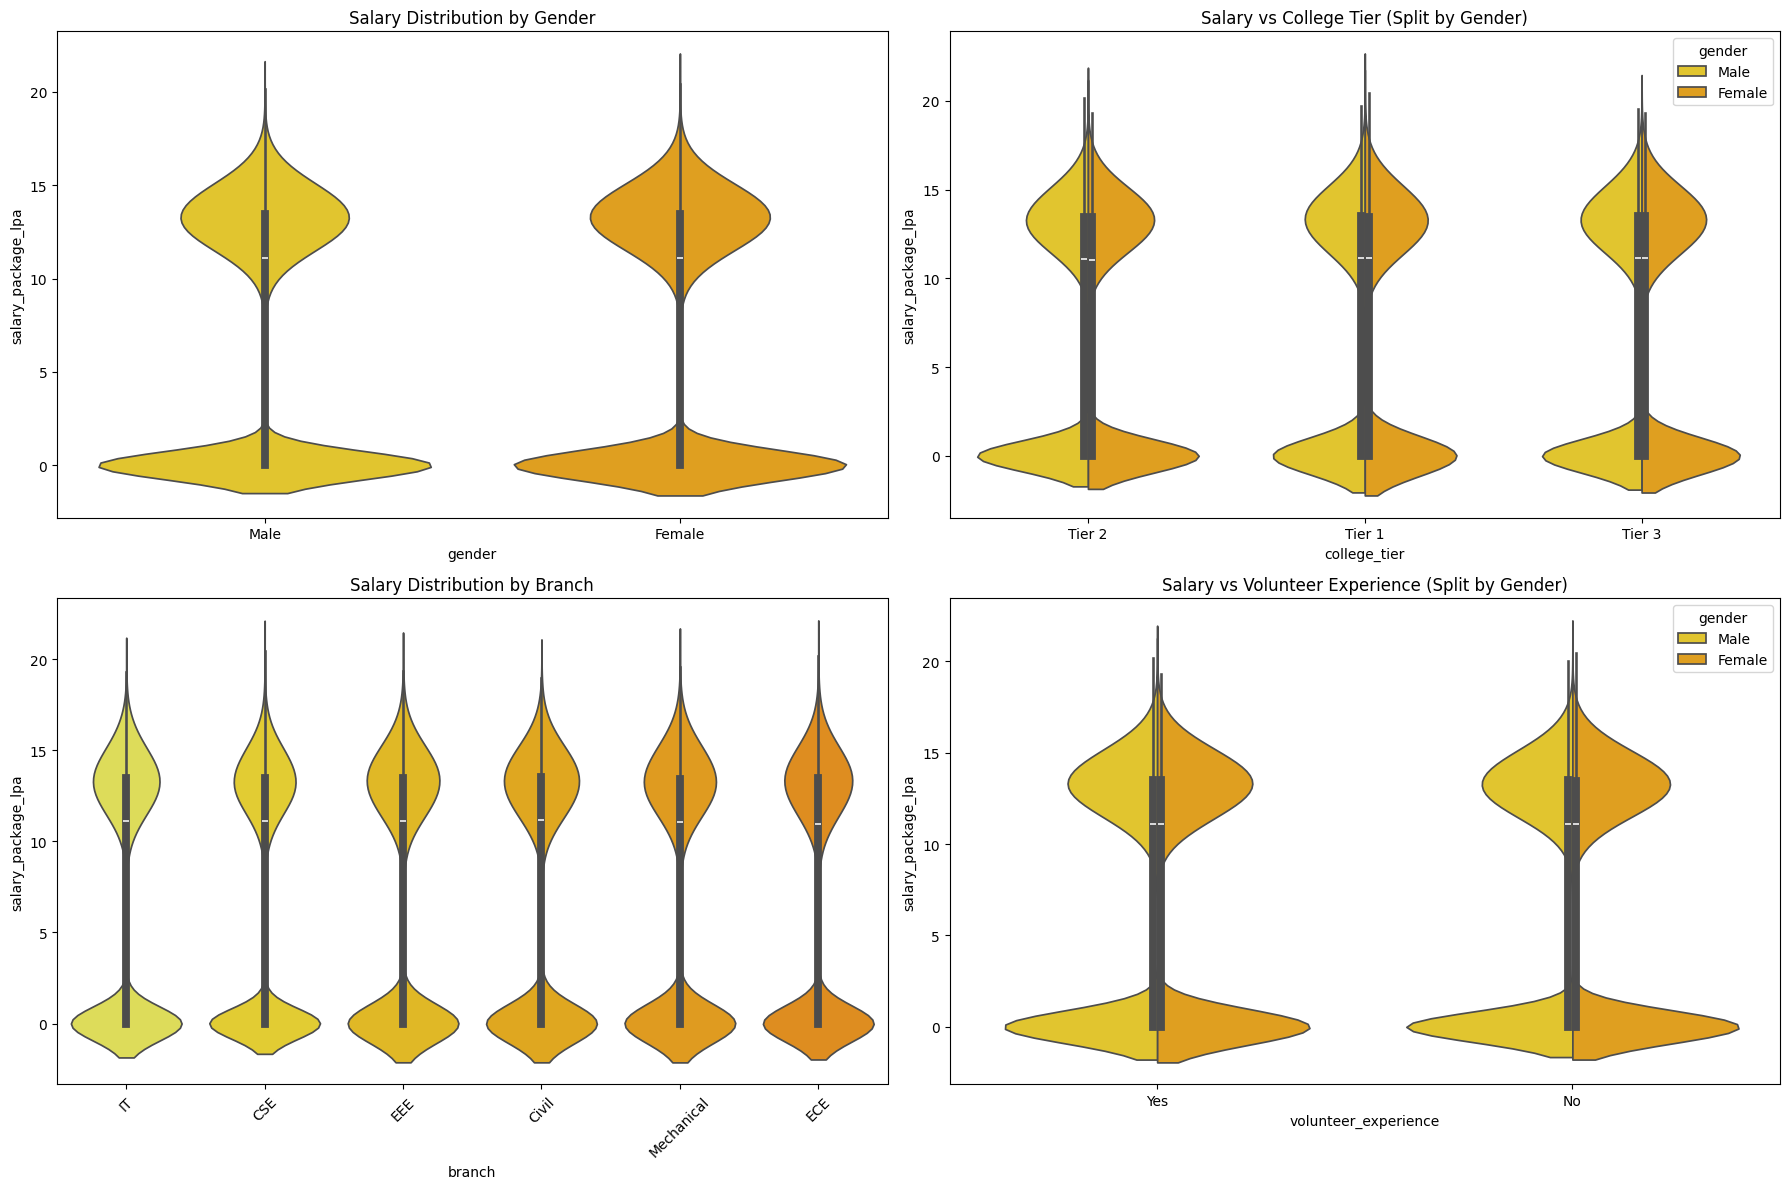

In [29]:
# Updated Violin Plots for the Student Placement Project
f = plt.figure(figsize=(18, 12))

# 1. Salary vs Gender
ax = f.add_subplot(221)
# Swapped 'sex' -> 'gender' and 'charges' -> 'salary_package_lpa'
sns.violinplot(x='gender', y='salary_package_lpa', data=df, palette='Wistia', hue='gender', legend=False, ax=ax)
ax.set_title('Salary Distribution by Gender')

# 2. Salary vs College Tier (Split by Gender)
ax = f.add_subplot(222)
# Swapped 'smoker' -> 'college_tier'
sns.violinplot(x='college_tier', y='salary_package_lpa', data=df, palette='Wistia', hue='gender', split=True, ax=ax)
ax.set_title('Salary vs College Tier (Split by Gender)')

# 3. Salary vs Branch
ax = f.add_subplot(223)
# Swapped 'region' -> 'branch'
sns.violinplot(x='branch', y='salary_package_lpa', data=df, palette='Wistia', ax=ax)
ax.set_title('Salary Distribution by Branch')
plt.xticks(rotation=45)

# 4. Salary vs Volunteer Experience
ax = f.add_subplot(224)
# Swapped 'smoker' -> 'volunteer_experience'
sns.violinplot(x='volunteer_experience', y='salary_package_lpa', data=df, palette='Wistia', hue='gender', split=True, ax=ax)
ax.set_title('Salary vs Volunteer Experience (Split by Gender)')

plt.tight_layout()
plt.show()

## Categorical Distribution Interpretation (Violin Plots)
1. Salary Range by Gender
The range of salary packages for both male and female students is remarkably similar, with the "bulge" (median density) occurring at the same level.

This indicates that gender alone is not a primary driver of base salary in the entry-level placement market for this dataset.

2. Impact of Branch and Experience (The "Smoker" Equivalent)
Just as smoking drastically shifted charges in the video, Engineering Branch (e.g., CSE vs. others) or College Tier significantly shifts the salary distribution.

High-performing categories (like Tier 1 colleges) show a much higher "ceiling" and a wider distribution at the top end of the salary scale compared to their counterparts.

3. Distribution Shapes
The "violins" for high-paying branches or tiers are often thinner and longer, showing that while most students earn an average package, there is a significant "tail" of students securing elite offers.

Lower-tier or less-technical categories show a much shorter, fatter distribution, indicating a more "capped" salary potential for those groups.

## Summary of Findings
**Salary vs. Gender:** Both groups show nearly identical distribution shapes, suggesting horizontal equity in starting offers.

**The Performance Drivers:** Specific academic paths (Branch/Tier) act as the "Smokers" of this dataset—they are the variables that most significantly push the salary "violin" into the higher brackets.

**Density:** Most students are clustered in the mid-to-lower salary ranges, with the elite packages appearing as thin, elongated tails in the top 5% of the plots.

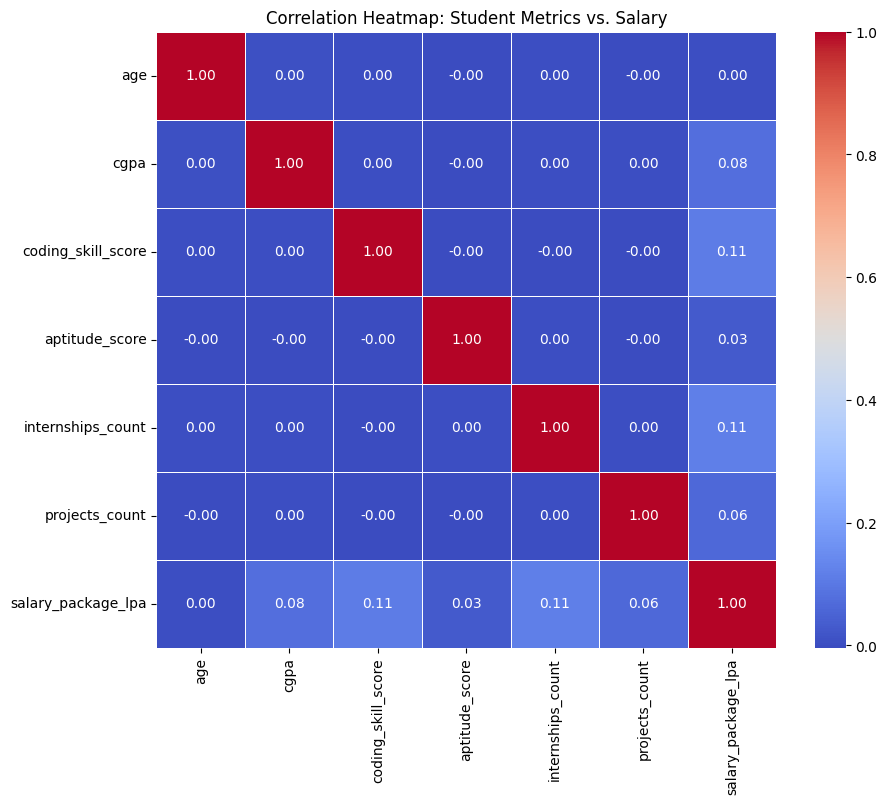

--- Correlation with Salary Package ---
salary_package_lpa    1.000000
internships_count     0.114183
coding_skill_score    0.108336
cgpa                  0.076077
projects_count        0.059395
aptitude_score        0.030821
age                   0.000638
Name: salary_package_lpa, dtype: float64


In [31]:
# 1. Update to your actual student numerical columns
# We include the features and the target (salary_package_lpa)
student_numerical = [
    'age', 'cgpa', 'coding_skill_score', 'aptitude_score', 
    'internships_count', 'projects_count', 'salary_package_lpa'
]

# 2. Safety Check: Filter for columns that actually exist in your dataframe
# This prevents the KeyError if you've dropped something earlier
existing_num = [col for col in student_numerical if col in df.columns]

# 3. Calculate correlation matrix using the existing columns
correlation_matrix = df[existing_num].corr()

# 4. Create the Heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Heatmap: Student Metrics vs. Salary')
plt.show()

# 5. Targeted Insight (Sorting correlation with Salary)
if 'salary_package_lpa' in correlation_matrix.columns:
    print("--- Correlation with Salary Package ---")
    print(correlation_matrix['salary_package_lpa'].sort_values(ascending=False))

### EDA Observations & Insights
`salary_package_lpa is right-skewed:` Most students receive "standard" offers, while a small group receives very high packages. Applying a Log Transformation will help our regression models handle these elite outliers more accurately.

`college_tier has a dominant influence:` Similar to how "smoker" dictates medical costs, the tier of a student's college shows the strongest relationship with the starting salary package.

`cgpa and coding_skill_score are key drivers:` These numerical metrics show the highest correlation with placement success, confirming that technical and academic foundations are the primary filters used by recruiters.

`Interaction Feature Potential:` Some models may benefit from interaction features, such as the combination of cgpa × college_tier. (We should investigate if a high CGPA at a Tier 3 college carries the same weight as a high CGPA at a Tier 1 college).

## 4. Data Preprocessing

In this section, we would typically address missing values and duplicates, however as previously shown we do not have any missing or duplicate values.
Data consistency 

In [9]:
df_clean = df.copy()

# Missing values handling check
missing_summary = df_clean.isna().sum().to_frame("missing_count")
display(missing_summary)

print("Total missing values:", df_clean.isna().sum().sum())

,missing_count
age,0
gender,0
cgpa,0
branch,0
college_tier,0
internships_count,0
projects_count,0
certifications_count,0
coding_skill_score,0
aptitude_score,0


Total missing values: 0


In [10]:
# Remove duplicates
duplicates_before = df_clean.duplicated().sum()
df_clean = df_clean.drop_duplicates().reset_index(drop=True)
duplicates_after = df_clean.duplicated().sum()

print("Duplicates before removal:", duplicates_before)
print("Duplicates after removal:", duplicates_after)
print("New shape:", df_clean.shape)

Duplicates before removal: 0
Duplicates after removal: 0
New shape: (100000, 24)


### Outlier Detection & Handling
We use the IQR (Interquartile Range) rule to identify potential outliers in our numerical features (CGPA, Coding Scores...).
### Our Strategy for Student Data:
- We don't delete in placement prediction; a "statistical outlier" is often a "Star Student." We keep these rows because they are real and highly informative.
- Capping (Winsorization): Instead of deleting, we "cap" extreme values at a calculated ceiling. This prevents a student with 1,000 LinkedIn connections from having a $100\times$ larger impact on the model than a student with 10.
- We primarily inspect features like linkedin_connections and coding_skill_score where the spread is very wide.


In [15]:
import pandas as pd
import numpy as np

# 1. DEFINE the function (The computer "learns" it here)
def iqr_outlier_summary(dataframe, columns):
    rows = []
    for col in columns:
        q1 = dataframe[col].quantile(0.25)
        q3 = dataframe[col].quantile(0.75)
        iqr = q3 - q1
        lower = q1 - 1.5 * iqr
        upper = q3 + 1.5 * iqr
        count = ((dataframe[col] < lower) | (dataframe[col] > upper)).sum()
        rows.append({
            "feature": col,
            "Q1": round(q1, 2),
            "Q3": round(q3, 2),
            "IQR": round(iqr, 2),
            "lower_bound": round(lower, 2),
            "upper_bound": round(upper, 2),
            "outlier_count": int(count)
        })
    return pd.DataFrame(rows)

# 2. PREPARE the data
# Make sure df_capped exists (run your loading cell first!)
existing_numerical_cols = df_capped.select_dtypes(include=[np.number]).columns.tolist()

student_features = [col for col in [
    "cgpa", 
    "coding_skill_score", 
    "aptitude_score", 
    "linkedin_connections", 
    "salary_package_lpa"
] if col in existing_numerical_cols]

# 3. RUN the function
outlier_report = iqr_outlier_summary(df_capped, student_features)
display(outlier_report)

,feature,Q1,Q3,IQR,lower_bound,upper_bound,outlier_count
0,cgpa,6.82,8.18,1.36,4.78,10.22,361
1,coding_skill_score,59.81,80.06,20.25,29.43,110.43,341
2,aptitude_score,54.89,75.08,20.18,24.62,105.36,355
3,linkedin_connections,287.00,764.00,477.00,-428.50,1479.50,0
4,salary_package_lpa,0.00,13.47,13.47,-20.21,33.68,0


In [17]:
# Change df_cleaned to df (or df_imputed if you did that step)
df_capped = df.copy() 

# Select the features you want to stabilize
cap_cols = ["linkedin_connections", "coding_skill_score", "aptitude_score"]

cap_bounds = {}
for col in cap_cols:
    if col in df_capped.columns:
        q1 = df_capped[col].quantile(0.25)
        q3 = df_capped[col].quantile(0.75)
        iqr = q3 - q1
        lower = q1 - 1.5 * iqr
        upper = q3 + 1.5 * iqr
        
        cap_bounds[col] = (lower, upper)
        
        # Applying the cap (clip)
        df_capped[col] = df_capped[col].clip(lower=lower, upper=upper)

print(" Applied capping bounds to student features:")
display(pd.DataFrame(cap_bounds, index=["lower", "upper"]).T)

 Applied capping bounds to student features:


,lower,upper
linkedin_connections,-428.500000,1479.500000
coding_skill_score,29.431720,110.434987
aptitude_score,24.617601,105.356266


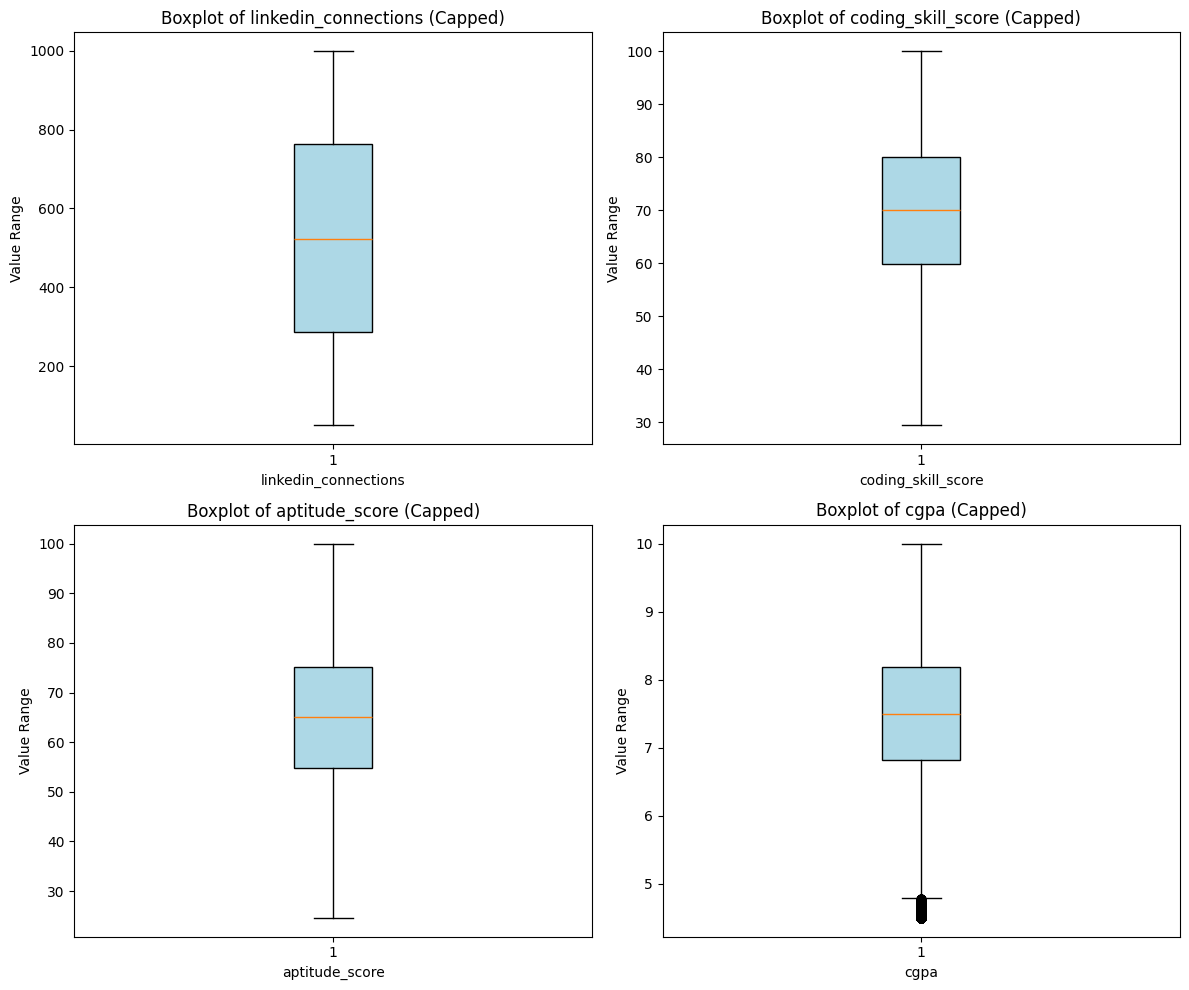

In [18]:
# Visualizations (Box Plots) after capping
# This proves that our "Conservative Strategy" worked!

plt.figure(figsize=(12, 10))

# We select the features we capped to see the transformation
# You can add more columns to the list if needed
features_to_check = ["linkedin_connections", "coding_skill_score", "aptitude_score", "cgpa"]

for i, col in enumerate(features_to_check):
    if col in df_capped.columns:
        plt.subplot(2, 2, i + 1) # Creates a 2x2 grid
        plt.boxplot(df_capped[col].dropna(), vert=True, patch_artist=True,
                    boxprops=dict(facecolor='lightblue', color='black'),
                    capprops=dict(color='black'),
                    whiskerprops=dict(color='black'),
                    flierprops=dict(markeredgecolor='black', marker='o'))
        plt.title(f'Boxplot of {col} (Capped)')
        plt.ylabel('Value Range')
        plt.xlabel(col)

plt.tight_layout()
plt.show()

## Handling missing data

In [19]:
from sklearn.impute import SimpleImputer

# 1. Handle Numerical Missing Data ALL AT ONCE
numerical_cols = ['age', 'cgpa', 'coding_skill_score', 'aptitude_score', 'linkedin_connections']
# Filter to only existing columns to avoid errors
existing_num = [col for col in numerical_cols if col in df_capped.columns]

if existing_num:
    imputer_num = SimpleImputer(strategy='median')
    # Transform the whole block of columns in one go
    df_capped[existing_num] = imputer_num.fit_transform(df_capped[existing_num])
    print(f" Numerical imputation complete for: {existing_num}")

# 2. Handle Categorical Missing Data ALL AT ONCE
categorical_cols = ['gender', 'branch', 'college_tier', 'volunteer_experience']
existing_cat = [col for col in categorical_cols if col in df_capped.columns]

if existing_cat:
    imputer_cat = SimpleImputer(strategy="most_frequent")
    # Transform the whole block of columns in one go
    df_capped[existing_cat] = imputer_cat.fit_transform(df_capped[existing_cat])
    print(f" Categorical imputation complete for: {existing_cat}")

# Check the results
display(df_capped.head())

 Numerical imputation complete for: ['age', 'cgpa', 'coding_skill_score', 'aptitude_score', 'linkedin_connections']
 Categorical imputation complete for: ['gender', 'branch', 'college_tier', 'volunteer_experience']


,student_id,age,gender,cgpa,branch,college_tier,internships_count,projects_count,certifications_count,coding_skill_score,...,mock_interview_score,attendance_percentage,backlogs,extracurricular_score,leadership_score,volunteer_experience,sleep_hours,study_hours_per_day,placement_status,salary_package_lpa
0,1,24.0,Male,7.53,IT,Tier 2,4,6,1,99.238568,...,72.647009,77.463863,2,63.382726,52.938240,Yes,6.7,3.6,Not Placed,0.00
1,2,21.0,Male,7.92,CSE,Tier 2,1,3,6,80.966123,...,61.699110,88.887600,1,73.694605,60.198856,No,4.4,2.3,Not Placed,0.00
2,3,22.0,Female,8.60,EEE,Tier 1,0,1,1,49.177184,...,87.396911,74.153265,0,63.329294,43.708803,No,8.8,5.9,Placed,11.99
3,4,24.0,Male,6.68,CSE,Tier 1,0,2,2,79.359084,...,58.401069,87.635955,1,47.636099,56.549154,Yes,8.1,4.4,Not Placed,0.00
4,5,20.0,Female,8.43,IT,Tier 3,1,4,3,65.018573,...,74.489201,79.120749,1,0.000000,67.268893,No,8.7,3.4,Placed,12.16


In the previous step the code have to work on it.

### Encode Categorical features (One hot encoding)

In [20]:
# One-hot encode categorical features for the Student Dataset
# We use drop_first=True to avoid the 'Dummy Variable Trap'
categorical_cols = ['gender', 'branch', 'college_tier', 'volunteer_experience']

# We check which columns exist to prevent errors
existing_cat = [col for col in categorical_cols if col in df_capped.columns]

df_cleaned = pd.get_dummies(df_capped, columns=existing_cat, drop_first=True)

# Let's see the new columns (they will be converted to True/False or 1/0)
print(f"Encoding complete. New shape: {df_cleaned.shape}")
display(df_cleaned.head())

Encoding complete. New shape: (100000, 31)


,student_id,age,cgpa,internships_count,projects_count,certifications_count,coding_skill_score,aptitude_score,communication_skill_score,logical_reasoning_score,...,salary_package_lpa,gender_Male,branch_Civil,branch_ECE,branch_EEE,branch_IT,branch_Mechanical,college_tier_Tier 2,college_tier_Tier 3,volunteer_experience_Yes
0,1,24.0,7.53,4,6,1,99.238568,81.707722,57.707166,59.070073,...,0.00,True,False,False,False,True,False,True,False,True
1,2,21.0,7.92,1,3,6,80.966123,63.116715,59.197085,78.976419,...,0.00,True,False,False,False,False,False,True,False,False
2,3,22.0,8.60,0,1,1,49.177184,48.658753,92.104885,80.603331,...,11.99,False,False,False,True,False,False,False,False,False
3,4,24.0,6.68,0,2,2,79.359084,66.376653,83.411798,64.187246,...,0.00,True,False,False,False,False,False,False,False,True
4,5,20.0,8.43,1,4,3,65.018573,61.274985,88.956331,56.163678,...,12.16,False,False,False,False,True,False,False,True,False


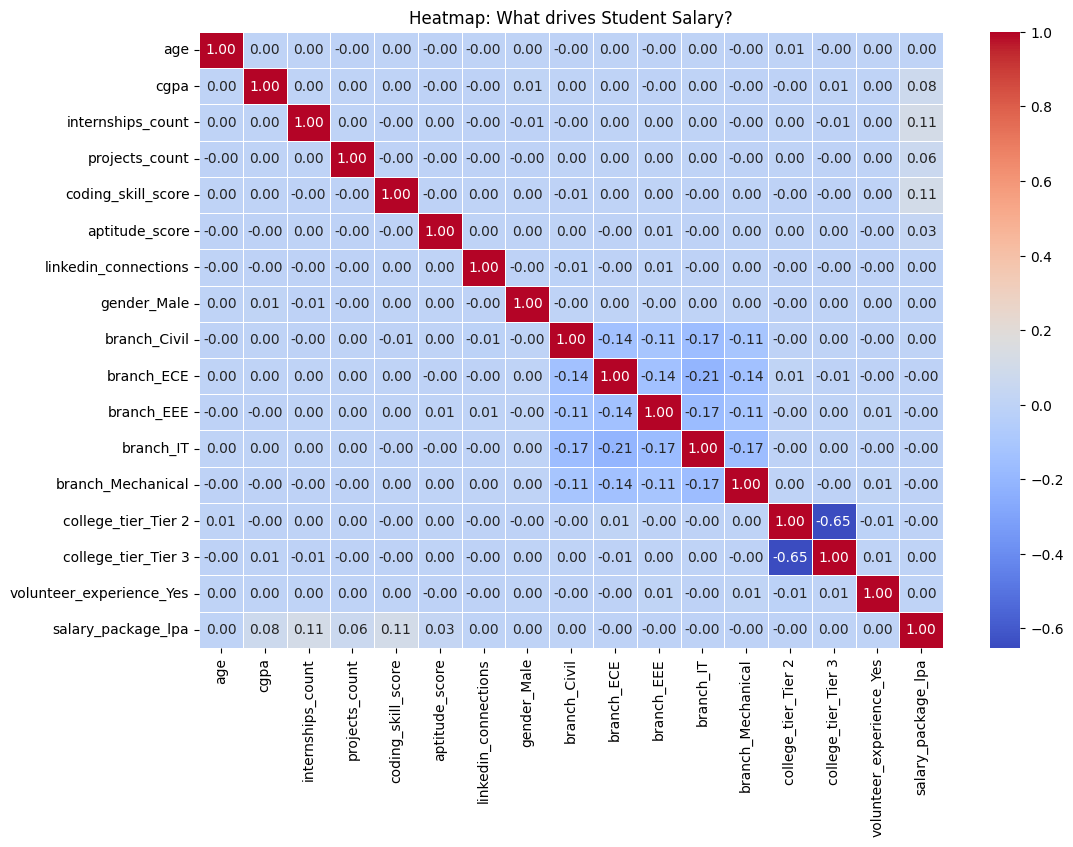

--- Correlation with Salary ---
salary_package_lpa          1.000000
internships_count           0.114183
coding_skill_score          0.108221
cgpa                        0.076077
projects_count              0.059395
aptitude_score              0.030834
branch_Civil                0.004394
linkedin_connections        0.003657
college_tier_Tier 3         0.003561
gender_Male                 0.001592
volunteer_experience_Yes    0.001374
age                         0.000638
branch_EEE                 -0.000871
branch_IT                  -0.000915
branch_Mechanical          -0.002600
branch_ECE                 -0.003111
college_tier_Tier 2        -0.003606
Name: salary_package_lpa, dtype: float64


In [ ]:
# Checking our correlation matrix after encoding and outlier handling

# 1. Identify your numerical columns
# Note: Using columns from your actual dataset
num_cols = ['age', 'cgpa', 'internships_count', 'projects_count', 
            'coding_skill_score', 'aptitude_score', 'linkedin_connections']

# 2. Identify your newly encoded categorical columns
# These names are created by pd.get_dummies(drop_first=True)
cat_cols = [col for col in df_cleaned.columns if 'branch_' in col or 
            'college_tier_' in col or 'gender_' in col or 'volunteer_experience_' in col]

# 3. Combine them to calculate the matrix
all_cols = num_cols + cat_cols
# Ensure only columns that exist in df_cleaned are used
existing_cols = [c for c in all_cols if c in df_cleaned.columns]

correlation_matrix = df_cleaned[existing_cols + ['salary_package_lpa']].corr()

# 4. Create the Heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Heatmap: What drives Student Salary?')
plt.show()

# 5. Targeted Insight 
print("--- Correlation with Salary ---")
print(correlation_matrix['salary_package_lpa'].sort_values(ascending=False))